# 01 — Data dan Preprocessing: Eksplorasi, Pembersihan Teks & WordCloud

Notebook ini merupakan tahap pertama dalam pipeline analisis sentimen tweet banjir untuk naskah Tesis:
1. **Pemuatan Data (`read datav2 = data`)**: Membaca dataset korpus tweet bencana banjir, inspeksi struktur data, dan analisis distribusi label awal.
2. **Preprocessing Data**:
   - Pembersihan Regex Non-Destruktif: menghapus URL, mention `@user`, hashtag simbol (mempertahankan kata), karakter non-alfanumerik/HTML, spasi ganda.
   - Normalisasi Slang/Alay: standardisasi kata informal bahasa Indonesia menggunakan kamus leksikon resmi (`kamus/colloquial-indonesian-lexicon.csv`).
   - Pembentukan DataFrame Baru: menghasilkan `data_bersih_siap_pakai.csv` yang bersih dan siap pakai untuk pemodelan.
3. **Analisis WordCloud**:
   - WordCloud keseluruhan teks bersih.
   - WordCloud komparatif per kelas sentimen (Positif, Netral, Negatif) dengan penyaringan stopwords Indonesia.
   - Analisis Top 15 frekuensi kata per kategori sentimen.

In [1]:
import os
import sys
import re
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan library wordcloud terpasang
try:
    from wordcloud import WordCloud, STOPWORDS
except ImportError:
    !pip install wordcloud
    from wordcloud import WordCloud, STOPWORDS

# Setup working directory to project root
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Direktori Kerja:", Path.cwd())

# Setup path fleksibel (lokal maupun Kaggle/Colab)
def resolve_path(filename):
    """Cari file secara rekursif di Kaggle /kaggle/input atau direktori lokal."""
    if Path("/kaggle/input").exists():
        for root, _dirs, files in os.walk("/kaggle/input"):
            if filename in files:
                found = os.path.join(root, filename)
                print(f"[resolve_path] Ditemukan di Kaggle: {found}")
                return found
    candidates = [
        Path(f"Data/processed/{filename}"),
        Path(f"Data/raw/{filename}"),
        Path(f"Data/{filename}"),
        Path(f"kamus/{filename}"),
        Path(f"../Data/processed/{filename}"),
        Path(f"../Data/raw/{filename}"),
        Path(f"../Data/{filename}"),
        Path(f"../kamus/{filename}"),
        Path(filename),
    ]
    for p in candidates:
        if p.exists():
            print(f"[resolve_path] Ditemukan lokal: {p}")
            return str(p)
    return filename

# Kunci seed deterministik
SEED = 42
np.random.seed(SEED)
print("Environment siap. Seed =", SEED)

Direktori Kerja: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT
Environment siap. Seed = 42


## 1. Pemuatan Data Mentah (`read datav2 = data`)
Membaca dataset korpus tweet banjir mentah dan melakukan audit integritas data awal.

In [2]:
# Membaca data mentah banjir
raw_path = resolve_path('data_banjir.csv')
if not Path(raw_path).exists():
    raw_path = resolve_path('banjir.csv')

df_raw = pd.read_csv(raw_path)
print(f"Data mentah berhasil dimuat: {len(df_raw):,} baris, {df_raw.shape[1]} kolom dari '{raw_path}'")
print("\n--- Daftar Kolom ---")
print(list(df_raw.columns))
print("\n--- 5 Baris Pertama ---")
display(df_raw.head())

[resolve_path] Ditemukan lokal: Data\data_banjir.csv
Data mentah berhasil dimuat: 8,648 baris, 8 kolom dari 'Data\data_banjir.csv'

--- Daftar Kolom ---
['text', 'clean_text', 'created_at', 'keyword', 'processed_text', 'sentimen', 'label', 'emoticon']

--- 5 Baris Pertama ---


,text,clean_text,created_at,keyword,processed_text,sentimen,label,emoticon
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit menemukan siapa pemilik kayu yg m...,2026-01-13,Banjir Sumatra 2025,polisi sulit temu siapa milik kayu sebab banji...,negatif,0,NaN
1,Seorang Ibu harus memanjat tebing demi membawa...,seorang ibu harus memanjat tebing demi membawa...,2026-01-13,Banjir Sumatra 2025,orang ibu panjat tebing bawa bayi puskesmas ga...,negatif,0,NaN
2,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,waspada banjir pesisir durasi januari,2026-01-13,Banjir Sumatra 2025,waspada banjir pesisir durasi januari,netral,1,NaN
3,Konsistensi Toba Pulp Lestari menerapkan prins...,konsistensi toba pulp lestari menerapkan prins...,2026-01-12,Banjir Sumatra 2025,konsistensi toba pulp lestari terap prinsip la...,netral,1,NaN
4,BANJIR bandang yang menghancurkan kawasan Aceh...,banjir bandang yang menghancurkan kawasan aceh...,2026-01-12,Banjir Sumatra 2025,banjir bandang hancur kawasan aceh sumatra uta...,negatif,0,NaN


### 1.1 Pemeriksaan Kualitas Data & Distribusi Label Sentimen
Pemeriksaan nilai yang hilang (*missing values*), teks duplikat, dan rasio ketimpangan kelas (*class imbalance*).

Jumlah Missing Values per Kolom:
text                 0
clean_text           0
created_at           0
keyword              0
processed_text       1
sentimen             0
label                0
emoticon          8483
dtype: int64

Jumlah tweet duplikat: 0 baris

--- Distribusi Sentimen Awal ---


,Jumlah,Persentase (%)
sentimen,,
Negatif,4686,54.19
Positif,2452,28.35
Netral,1510,17.46


C:\Windows\Temp\ipykernel_10748\2620344880.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_raw, x='sentimen', order=['Negatif', 'Netral', 'Positif'], palette=palette)


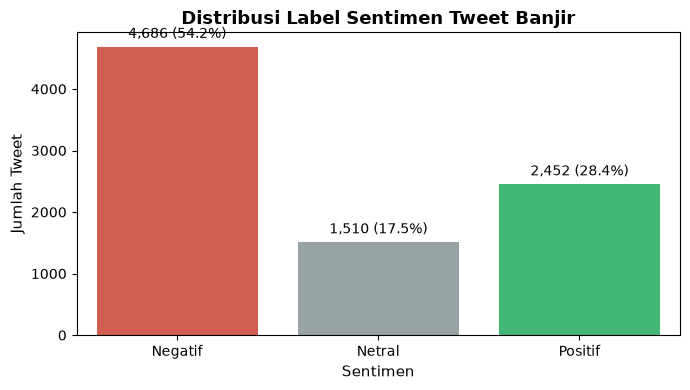

In [3]:
# Pengecekan Missing Value dan Duplikat
print("Jumlah Missing Values per Kolom:")
print(df_raw.isnull().sum())
print(f"\nJumlah tweet duplikat: {df_raw['text'].duplicated().sum():,} baris")

# Standardisasi Nama Label Sentimen (Capitalized: Negatif, Netral, Positif)
label_mapping = {0: "Negatif", 1: "Netral", 2: "Positif"}
if 'sentimen' not in df_raw.columns:
    df_raw['sentimen'] = df_raw['label'].map(label_mapping)
else:
    df_raw['sentimen'] = df_raw['sentimen'].astype(str).str.capitalize()

dist_df = pd.DataFrame({
    'Jumlah': df_raw['sentimen'].value_counts(),
    'Persentase (%)': (df_raw['sentimen'].value_counts(normalize=True) * 100).round(2)
})
print("\n--- Distribusi Sentimen Awal ---")
display(dist_df)

# Visualisasi Distribusi Sentimen
plt.figure(figsize=(7, 4))
palette = {'Negatif': '#e74c3c', 'Netral': '#95a5a6', 'Positif': '#2ecc71'}
ax = sns.countplot(data=df_raw, x='sentimen', order=['Negatif', 'Netral', 'Positif'], palette=palette)
plt.title("Distribusi Label Sentimen Tweet Banjir", fontsize=13, fontweight='bold')
plt.xlabel("Sentimen", fontsize=11)
plt.ylabel("Jumlah Tweet", fontsize=11)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,} ({p.get_height()/len(df_raw)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 4),
                textcoords='offset points')
plt.tight_layout()
plt.show()

## 2. Preprocessing Data: Pembersihan Regex & Normalisasi Slang
Tahapan pra-pemrosesan teks terisolasi dan non-destruktif:
1. **Pembersihan Regex**:
   - Menghapus tautan web (`https?://...`, `t.co/...`).
   - Menghapus mention Twitter (`@username`).
   - Menghapus simbol hashtag namun mempertahankan katanya (`#banjir` $\rightarrow$ `banjir`).
   - Menghapus karakter non-alfanumerik, tanda baca berlebih, dan entitas HTML.
   - Mengubah teks menjadi huruf kecil (*case folding*).
   - Menghapus spasi ganda dan *strip whitespace*.
2. **Normalisasi Kata Slang / Alay**:
   - Memetakan kata-kata tidak baku ke kata formal menggunakan kamus leksikon resmi (`kamus/colloquial-indonesian-lexicon.csv`).
3. **Pembentukan DataFrame Baru**:
   - Menghasilkan DataFrame baru siap pakai dan mengekspornya ke format CSV.

In [4]:
def clean_regex(text):
    """Pembersihan teks menggunakan Regular Expression."""
    text = str(text)
    # 1. Hapus URL / Link
    text = re.sub(r'https?://\S+|www\.\S+|t\.co/\S+', '', text)
    # 2. Hapus Mention (@user)
    text = re.sub(r'@\w+', '', text)
    # 3. Hapus simbol hashtag, pertahankan kata
    text = re.sub(r'#(\w+)', r'\1', text)
    # 4. Hapus HTML entities
    text = re.sub(r'&\w+;', ' ', text)
    # 5. Hapus karakter non-alfanumerik (pertahankan huruf, angka, dan spasi)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # 6. Lowercase / Case Folding
    text = text.lower()
    # 7. Normalisasi spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Contoh Uji Fungsi clean_regex:")
sample_dirty = "Banjir bandang parah di Jkt!! @BPBDJakarta @jokowi tolong evakuasi https://t.co/abc1234 #BanjirJakarta &amp; longsor :("
print("Sebelum :", sample_dirty)
print("Sesudah :", clean_regex(sample_dirty))

Contoh Uji Fungsi clean_regex:
Sebelum : Banjir bandang parah di Jkt!! @BPBDJakarta @jokowi tolong evakuasi https://t.co/abc1234 #BanjirJakarta &amp; longsor :(
Sesudah : banjir bandang parah di jkt tolong evakuasi banjirjakarta longsor


In [5]:
# Load Kamus Leksikon Slang/Alay
kamus_path = resolve_path('colloquial-indonesian-lexicon.csv')
df_kamus = pd.read_csv(kamus_path)
print(f"Kamus leksikon dimuat: {len(df_kamus):,} kata informal dari '{kamus_path}'")

# Buat dictionary pemetaan slang -> formal
slang_dict = dict(zip(df_kamus['slang'].astype(str).str.lower(), df_kamus['formal'].astype(str).str.lower()))

def normalize_slang(text, mapping_dict):
    """Mengganti kata informal/slang menjadi kata baku/formal."""
    words = str(text).split()
    normalized_words = [mapping_dict.get(w, w) for w in words]
    return ' '.join(normalized_words)

sample_slang = "bgt gak bs tdr krn aer msk rmh tlg bgt ya min"
print("Sebelum normalisasi slang :", sample_slang)
print("Sesudah normalisasi slang :", normalize_slang(sample_slang, slang_dict))

[resolve_path] Ditemukan lokal: kamus\colloquial-indonesian-lexicon.csv
Kamus leksikon dimuat: 15,006 kata informal dari 'kamus\colloquial-indonesian-lexicon.csv'
Sebelum normalisasi slang : bgt gak bs tdr krn aer msk rmh tlg bgt ya min
Sesudah normalisasi slang : banget enggak bisa tidur karena air masuk rumah tolong banget ya min


In [6]:
# Eksekusi Pipeline Pembersihan pada Seluruh Data
print("Menjalankan pipeline preprocessing teks...")
df_raw['regex_cleaned'] = df_raw['text'].apply(clean_regex)
df_raw['clean_text'] = df_raw['regex_cleaned'].apply(lambda x: normalize_slang(x, slang_dict))

# Filter baris yang kosong setelah dibersihkan jika ada
df_clean = df_raw[df_raw['clean_text'].str.strip() != ''].copy()
df_clean = df_clean.reset_index(drop=True)

print(f"Selesai! Total data bersih siap pakai: {len(df_clean):,} baris")

# Tampilkan perbandingan 5 sampel teks sebelum vs sesudah
sample_compare = df_clean[['text', 'clean_text', 'sentimen']].head(5)
for i, row in sample_compare.iterrows():
    print(f"\n--- Sampel #{i+1} [{row['sentimen'].upper()}] ---")
    print(f"Raw  : {row['text'][:120]}...")
    print(f"Clean: {row['clean_text'][:120]}...")

Menjalankan pipeline preprocessing teks...


Selesai! Total data bersih siap pakai: 8,648 baris

--- Sampel #1 [NEGATIF] ---
Raw  : Polisi : Sulit menemukan siapa pemilik kayu yg menyebabkan banjir Sumatra akhir 2025. Rakyat : Polisi Goblok, Percuma se...
Clean: polisi sulit menemukan siapa pemilik kayu yang menyebabkan banjir sumatra akhir 2025 rakyat polisi goblok percuma sekola...

--- Sampel #2 [NEGATIF] ---
Raw  : Seorang Ibu harus memanjat tebing demi membawa bayinya ke Puskesmas. Gampong (Desa) Sikundo, Aceh Barat, masih terisolas...
Clean: seorang ibu harus memanjat tebing demi membawa bayinya ke puskesmas gampong desa sikundo aceh barat masih terisolasi jal...

--- Sampel #3 [NETRAL] ---
Raw  : WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari 2026 2 3 803...
Clean: waspada banjir pesisir durasi 13 20 januari 2026 2 3 803...

--- Sampel #4 [NETRAL] ---
Raw  : Konsistensi Toba Pulp Lestari menerapkan prinsip keberlanjutan dalam operasi usahanya pantas diapresiasi dan didukung, i...
Clean: konsistensi toba pulp lestari menera

In [7]:
# Pembentukan DataFrame Baru (Siap Pakai) dan Ekspor ke CSV
cols_to_keep = ['text', 'clean_text', 'sentimen', 'label']
df_ready = df_clean[cols_to_keep].copy()

# Direktori output
out_dir = Path("Data/processed")
out_dir.mkdir(parents=True, exist_ok=True)
out_file = out_dir / "data_bersih_siap_pakai.csv"

df_ready.to_csv(out_file, index=False)
print(f"DataFrame baru berhasil disimpan ke: {out_file} ({len(df_ready):,} baris)")

# Jika di Kaggle, simpan juga ke working directory
if Path("/kaggle/working").exists():
    df_ready.to_csv("/kaggle/working/data_bersih_siap_pakai.csv", index=False)
    print("Salinan dataset juga disimpan di: /kaggle/working/data_bersih_siap_pakai.csv")

display(df_ready.head(5))

DataFrame baru berhasil disimpan ke: Data\processed\data_bersih_siap_pakai.csv (8,648 baris)


,text,clean_text,sentimen,label
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit menemukan siapa pemilik kayu yang...,Negatif,0
1,Seorang Ibu harus memanjat tebing demi membawa...,seorang ibu harus memanjat tebing demi membawa...,Negatif,0
2,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,waspada banjir pesisir durasi 13 20 januari 20...,Netral,1
3,Konsistensi Toba Pulp Lestari menerapkan prins...,konsistensi toba pulp lestari menerapkan prins...,Netral,1
4,BANJIR bandang yang menghancurkan kawasan Aceh...,banjir bandang yang menghancurkan kawasan aceh...,Negatif,0


## 3. Analisis & Visualisasi WordCloud
Visualisasi awan kata (*wordcloud*) untuk menganalisis karakteristik leksikal:
- Menggunakan daftar *stopwords* bahasa Indonesia untuk menyaring kata tugas/hubung.
- WordCloud dibentuk untuk **keseluruhan korpus** dan **masing-masing kelas sentimen** (Negatif, Netral, Positif).

In [8]:
# Daftar Stopwords Bahasa Indonesia
indonesian_stopwords = set([
    'dan', 'di', 'ke', 'dari', 'yang', 'ini', 'itu', 'pada', 'untuk', 'dengan', 'ada',
    'adalah', 'akan', 'atau', 'bisa', 'dalam', 'dia', 'harus', 'ia', 'juga', 'karena',
    'kita', 'mereka', 'oleh', 'saat', 'sudah', 'telah', 'tidak', 'tapi', 'bukan', 'lagi',
    'hanya', 'saja', 'jika', 'kalau', 'maka', 'tentang', 'seperti', 'kami', 'kamu', 'anda',
    'apa', 'siapa', 'mengapa', 'bagaimana', 'kapan', 'dimana', 'jadi', 'banyak', 'sangat',
    'bahkan', 'namun', 'masih', 'sedang', 'sama', 'pun', 'kok', 'sih', 'kan', 'dong', 'deh',
    'nih', 'tuh', 'ya', 'yah', 'lah', 'kah', 'nah', 'loh', 'oh', 'nya', 'yg', 'ga', 'gak',
    'nggak', 'tdk', 'bgt', 'dgn', 'dr', 'dlm', 'krn', 'sy', 'bapak', 'ibu', 'orang', 'hari',
    'rt', 'rw', 'banget', 'kayak', 'udah'
])

print(f"Daftar stopwords Indonesia: {len(indonesian_stopwords)} kata terdaftar.")

Daftar stopwords Indonesia: 91 kata terdaftar.


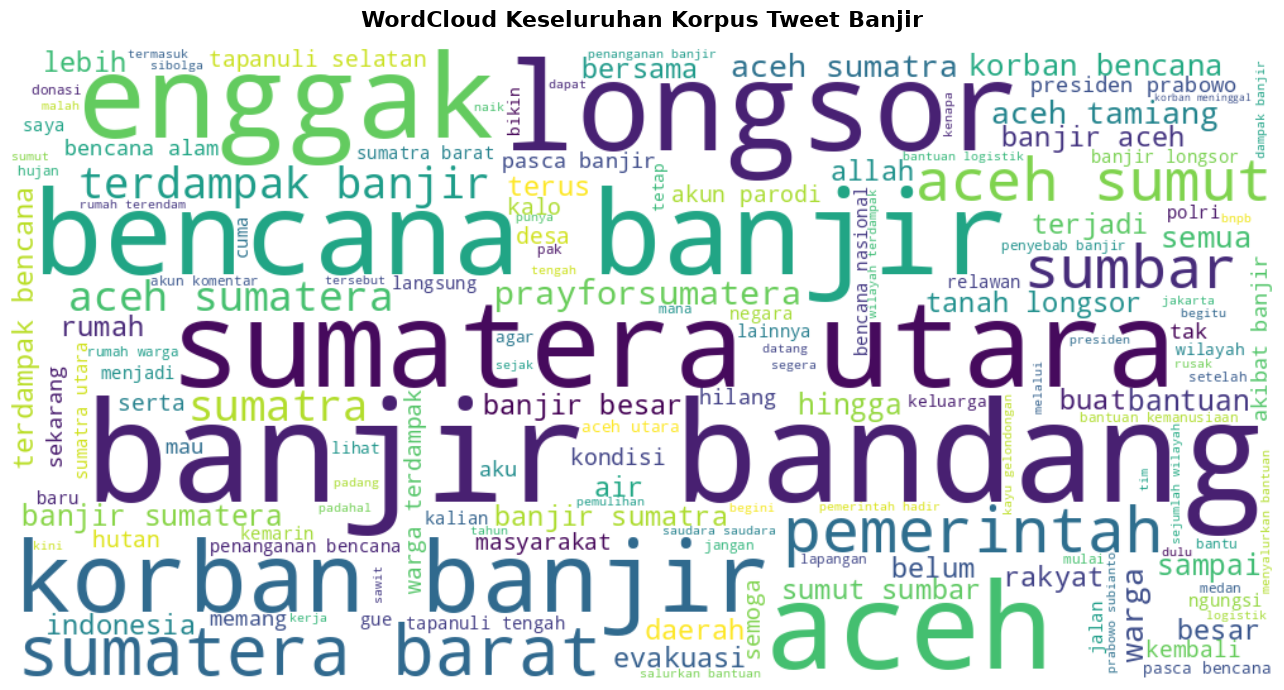

In [9]:
# 3.1 WordCloud Keseluruhan Teks Bersih
all_text = " ".join(df_ready['clean_text'].dropna().astype(str))

wc_all = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=indonesian_stopwords,
    colormap='viridis',
    max_words=150,
    random_state=SEED
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Keseluruhan Korpus Tweet Banjir", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

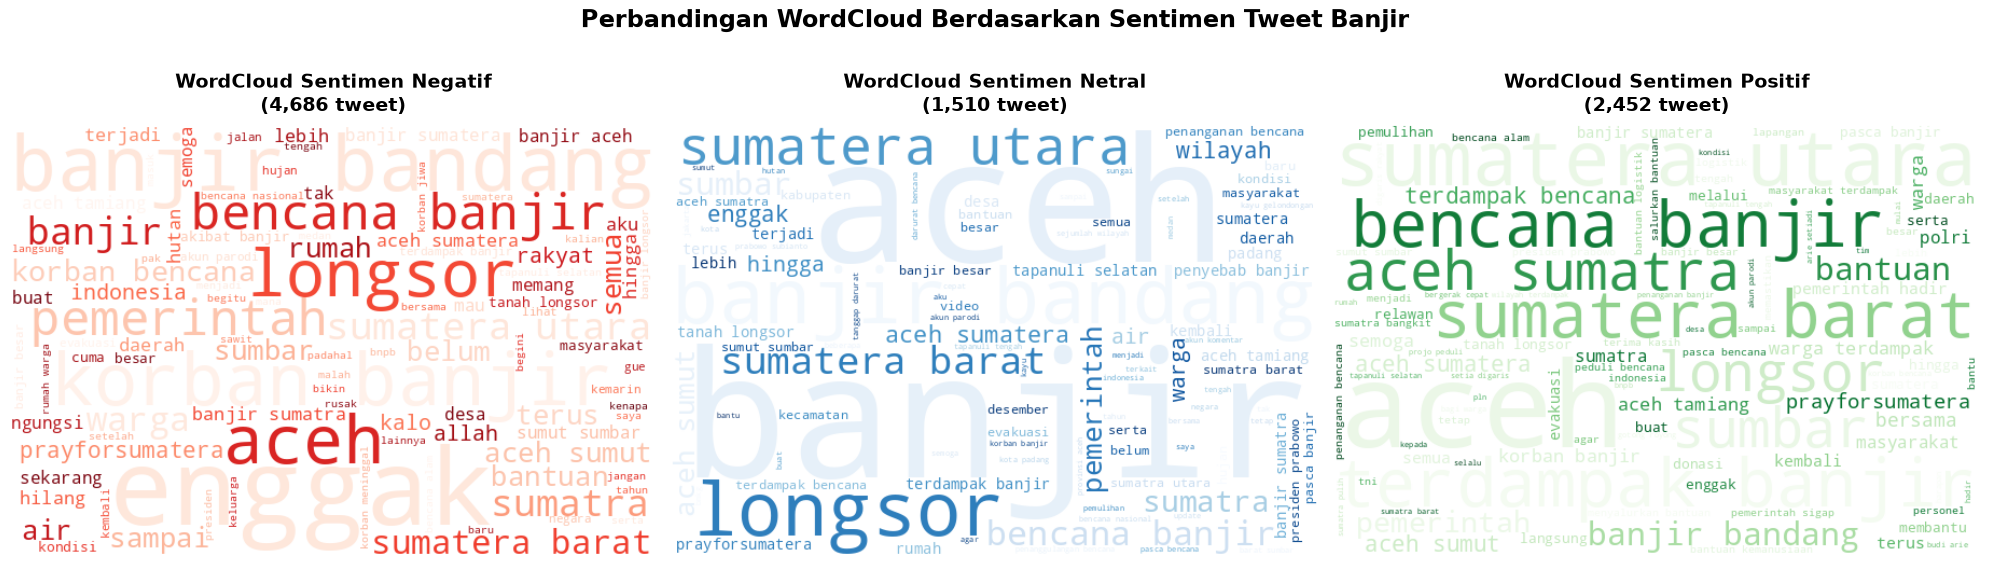

In [10]:
# 3.2 WordCloud Komparatif per Kelas Sentimen (Negatif, Netral, Positif)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

configs = [
    ('Negatif', 'Reds', axes[0]),
    ('Netral', 'Blues', axes[1]),
    ('Positif', 'Greens', axes[2])
]

for sentiment, cmap, ax in configs:
    subset = df_ready[df_ready['sentimen'].str.lower() == sentiment.lower()]['clean_text'].dropna().astype(str)
    subset_text = " ".join(subset)
    
    if len(subset_text.strip()) > 0:
        wc_sub = WordCloud(
            width=600,
            height=400,
            background_color='white',
            stopwords=indonesian_stopwords,
            colormap=cmap,
            max_words=100,
            random_state=SEED
        ).generate(subset_text)
        
        ax.imshow(wc_sub, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f"WordCloud Sentimen {sentiment}\n({len(subset):,} tweet)", 
                     fontsize=14, fontweight='bold', pad=10)

plt.suptitle("Perbandingan WordCloud Berdasarkan Sentimen Tweet Banjir", fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

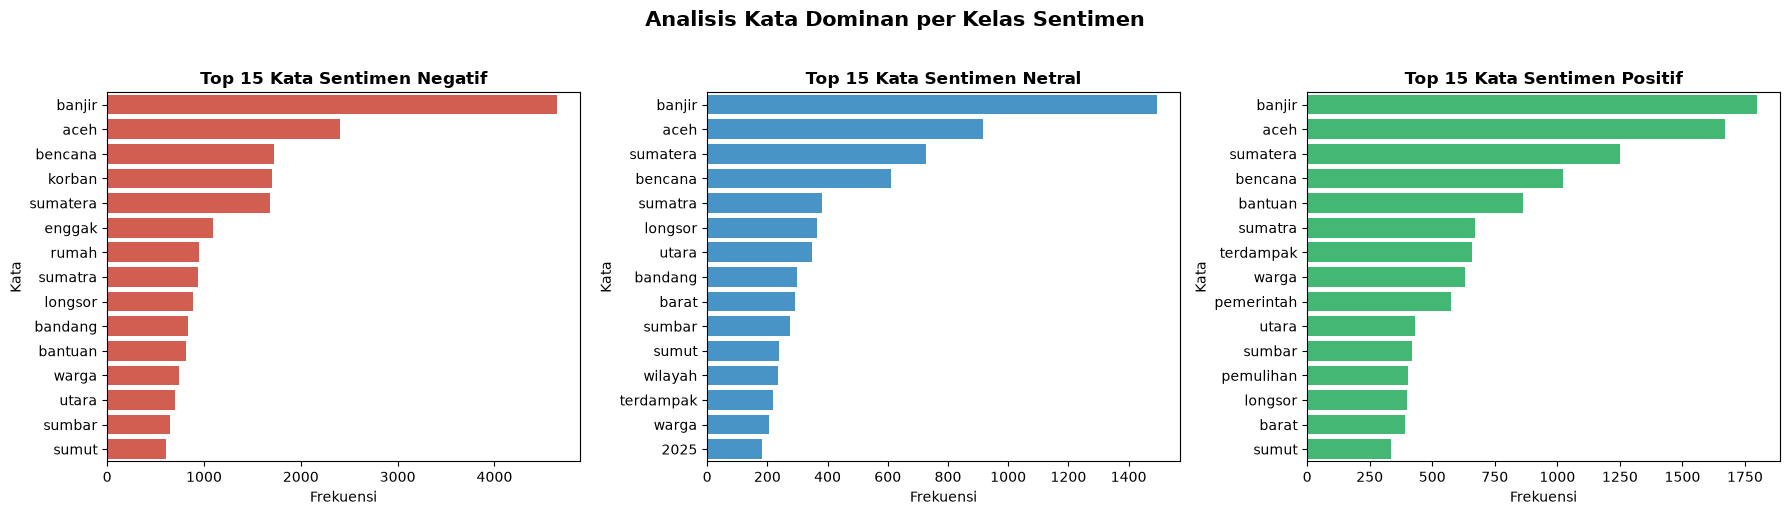

In [11]:
# 3.3 Visualisasi Top 15 Kata Paling Sering per Kelas Sentimen
from collections import Counter

plt.figure(figsize=(18, 5))

for i, (sentiment, color) in enumerate([('Negatif', '#e74c3c'), ('Netral', '#3498db'), ('Positif', '#2ecc71')]):
    subset = df_ready[df_ready['sentimen'].str.lower() == sentiment.lower()]['clean_text'].dropna().astype(str)
    subset_text = " ".join(subset)
    words = [w for w in subset_text.split() if w not in indonesian_stopwords and len(w) > 2]
    top_words = Counter(words).most_common(15)
    
    df_top = pd.DataFrame(top_words, columns=['kata', 'frekuensi'])
    
    plt.subplot(1, 3, i+1)
    sns.barplot(data=df_top, y='kata', x='frekuensi', color=color)
    plt.title(f"Top 15 Kata Sentimen {sentiment}", fontsize=12, fontweight='bold')
    plt.xlabel("Frekuensi", fontsize=10)
    plt.ylabel("Kata", fontsize=10)

plt.suptitle("Analisis Kata Dominan per Kelas Sentimen", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Kesimpulan Tahap Pra-Pemrosesan
1. Dataset mentah berhasil dibersihkan dari noise Twitter (URL, mention, simbol hashtag, dan karakter non-alfanumerik).
2. Kata informal berhasil distandarisasi menggunakan leksikon formal bahasa Indonesia.
3. DataFrame baru siap pakai telah disimpan ke `Data/processed/data_bersih_siap_pakai.csv` dengan integritas label dan jumlah baris terjaga.
4. Analisis Wordcloud mengonfirmasi variasi leksikal yang jelas antar kelas:
   - **Negatif**: Didominasi kata keluhan, kerusakan, kepanikan, kritik, dan dampak banjir.
   - **Netral**: Didominasi data faktual, tinggi muka air (TMA), debit air, lokasi, dan laporan cuaca.
   - **Positif**: Didominasi informasi bantuan, evakuasi warga, kerja bakti, penanganan cepat, dan doa.

Dataset bersih siap digunakan pada **Notebook 02** untuk pemodelan LSTM (5 varian penyeimbangan) dan IndoBERTweet-LoRA.